<a href="https://colab.research.google.com/github/rajaghv-dev/demo-python-utils/blob/master/Thirukural-Attention-Mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BertViz Interactive Tutorial: 2000+ Years Old AI
### Thirukkural by Thiruvalluvar and the Attention Mechanism

In the blog post, the structure of Thirukkural is compared to the Transformer Attention mechanism.

**The Core Analogy:**
* **Line 1 (The Context):** "If domestic life has love and virtue" (Sets up the Query & Key environment)
* **Line 2 (The Result):** "that itself is character and purpose" (Delivers the Value by referring back)

In the Kural, the word **"that" (அது)** in the second line relies entirely on connecting back to **"domestic life" (இல்வாழ்க்கை)** in the first line to make sense.

To see this math in action cleanly, we will use a much simpler, concrete sentence in the code below, but we will analyze it using this exact same Kural framework!

In [1]:
!pip install bertviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.4 MB/s eta 0:00:00


In [30]:
import transformers
transformers.logging.set_verbosity_error()
import torch
from transformers import BertTokenizer, BertModel

# We load the standard English model
model_version = 'bert-base-uncased'
model = BertModel.from_pretrained(model_version, output_attentions=True, output_hidden_states=True)
tokenizer = BertTokenizer.from_pretrained(model_version)

# We use the simple, concrete example to keep the math obvious
text = "The animal didn't cross the street because it was too tired."

inputs = tokenizer(text, return_tensors='pt')
input_ids = inputs['input_ids']
token_type_ids = inputs.get('token_type_ids', torch.zeros_like(input_ids))

with torch.no_grad():
    outputs = model(input_ids, token_type_ids=token_type_ids)
    attention = outputs.attentions

input_id_list = input_ids[0].tolist()
tokens = tokenizer.convert_ids_to_tokens(input_id_list)

print("Tokens representing our sentence:\n", tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Tokens representing our sentence:
 ['[CLS]', 'the', 'animal', 'didn', "'", 't', 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired', '.', '[SEP]']


### Step 1: Mapping the Analogy (Context vs Result)

Look at our simple sentence as if it were a Kural:
* **Clause 1 (Like Line 1):** "The animal didn't cross the street"
* **Clause 2 (Like Line 2):** "because it was too tired"

Just as **"that"** in the Kural points back to **"domestic life"**, the word **"it"** in our second clause needs to point back to the right word in the first clause. Does "it" mean the animal or the street?

**Why Look at Layer 9? (The Evidence)**
AI research (like the paper *"What Does BERT Look At?" by Clark et al., 2019*) shows that BERT divides language processing across its layers like an assembly line:
* **Early Layers (0-4):** Focus on basic grammar and neighboring words.
* **Middle Layers (5-9):** Specialize in syntax and "coreference resolution"—connecting pronouns to their specific targets.
* **Late Layers (10-11):** Focus on the overall overarching theme.

**The Kural Connection:** Think of this like reading the Kural. First, you read individual words (Early Layers). Then, you realize "that" (அது) is a reference, and your brain scans backward to find "domestic life" (Middle Layers like Layer 9). Finally, you grasp the moral of the poem (Late Layers).

Let's look at the consensus of all the attention heads in Layer 9 to see this reference resolution in action.

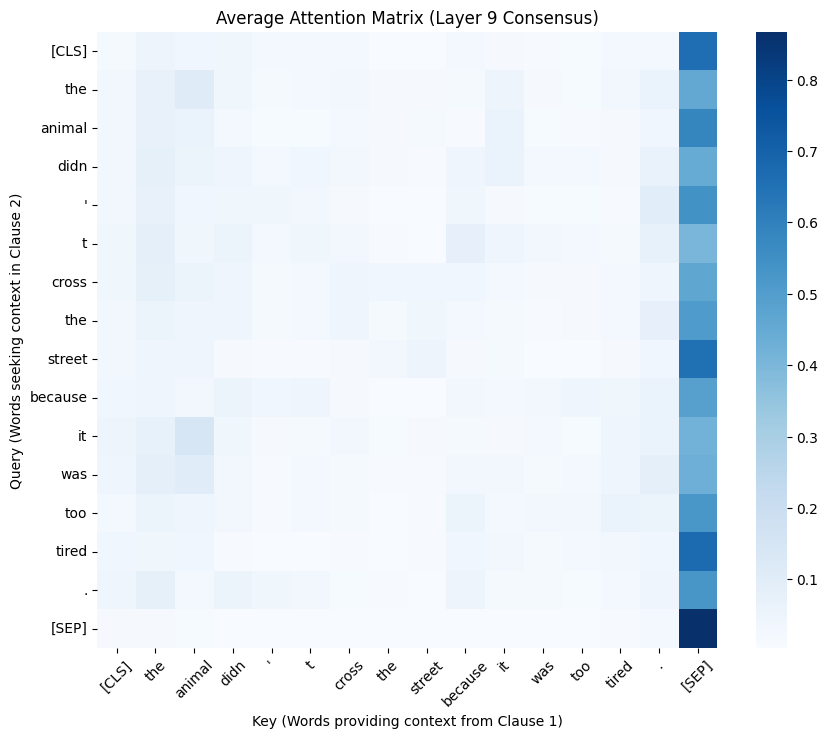

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Layer 9 (index 8) is heavily involved in resolving pronouns
layer_idx = 8

# Average the attention across all 12 heads in this layer to find the consensus
attn_matrix = attention[layer_idx][0].mean(dim=0).detach().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap='Blues')
plt.title(f"Average Attention Matrix (Layer {layer_idx+1} Consensus)")
plt.xlabel("Key (Words providing context from Clause 1)")
plt.ylabel("Query (Words seeking context in Clause 2)")
plt.xticks(rotation=45)
plt.show()

### Step 2: Zooming in on the Query

In Kural 45, you know the word "that" connects to "domestic life" because your human brain understands the semantics of relationships.

In our sentence, we know "it" connects to "animal". Let's isolate the attention weights just for the word **"it"** and see if the AI mathematically mimics this human intuition. We will highlight the candidate words: **animal** (green) and **street** (red).

--- Attention Consensus for the word 'it' ---
Attention to 'animal': 14.42%
Attention to 'street': 1.62%
---------------------------------------------


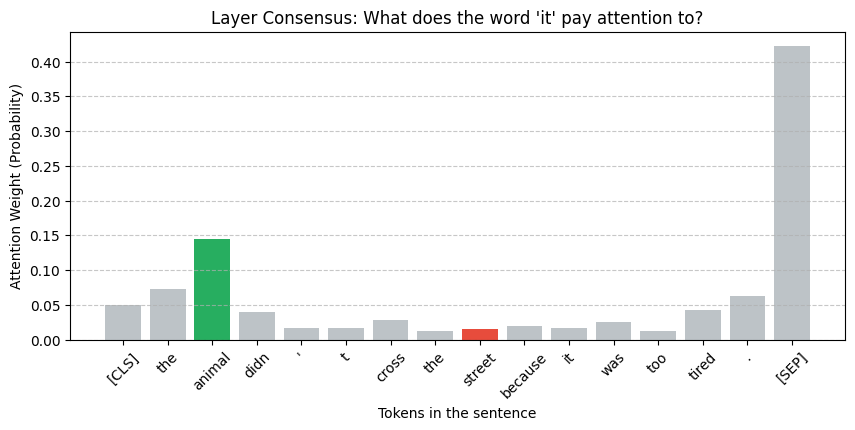

In [32]:
# Find the index for the word 'it'
it_index = tokens.index('it')

# Get the attention weights specifically for the word 'it'
it_attention = attn_matrix[it_index]

print("--- Attention Consensus for the word 'it' ---")
print(f"Attention to 'animal': {it_attention[tokens.index('animal')] * 100:.2f}%")
print(f"Attention to 'street': {it_attention[tokens.index('street')] * 100:.2f}%")
print("---------------------------------------------")

# Color candidates
colors = []
for t in tokens:
    if t == 'animal': colors.append('#27ae60') # Green
    elif t == 'street': colors.append('#e74c3c') # Red
    else: colors.append('#bdc3c7') # Grey

plt.figure(figsize=(10, 4))
plt.bar(range(len(tokens)), it_attention, color=colors, tick_label=tokens)
plt.title("Layer Consensus: What does the word 'it' pay attention to?")
plt.xlabel("Tokens in the sentence")
plt.ylabel("Attention Weight (Probability)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Step 3: The Library Analogy (Raw Math)

How did the AI overwhelmingly choose "animal"? This brings us to the blog's **Library Analogy**.

* **Query (Q):** The word `it` asks, *"What is tired?"*
* **Key (K):** The words `animal` and `street` offer their features.

During its massive reading of text during training, the AI learned that "tiredness" is a property of living creatures, not paved roads. Therefore, when the model multiplies (dot product) the internal Query vector for `it` against the Key vector for `animal`, it creates a massive spike in raw compatibility.

Let's extract those exact internal vectors and compute their raw mathematical match scores before they are turned into percentages.

### The Insight: The Geometry of Meaning

Whether it's a 2000-year-old Tamil couplet or a modern Transformer model calculating dot products, meaning relies on connection.

Thiruvalluvar structured his Kurals precisely so the human mind would naturally query the context of the first line to extract the value of the second. Thousands of years later, AI mathematically replicates this exact same process. Attention is truly the universal mechanism of understanding!

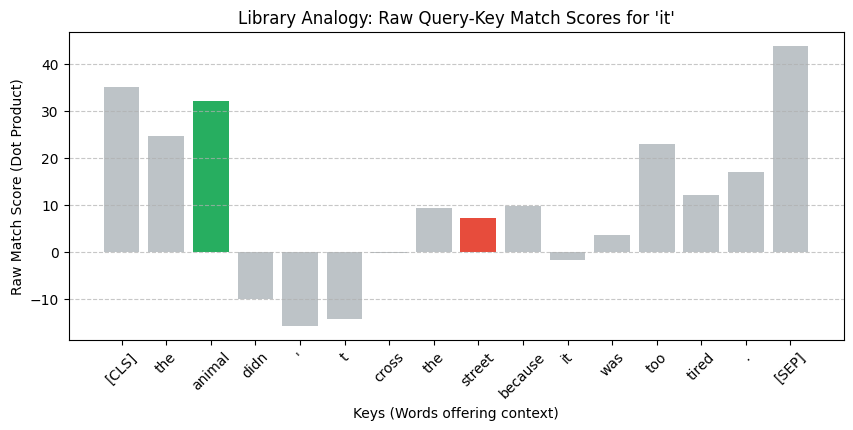

In [33]:
# We will use the already extracted outputs from Step 1
hidden_states = outputs.hidden_states[layer_idx]

# Get the Q and K projection matrices for Layer 9
query_layer = model.encoder.layer[layer_idx].attention.self.query
key_layer = model.encoder.layer[layer_idx].attention.self.key

# Let's look at a single head (Head 0) to keep the math clean
head_idx = 0
head_dim = model.config.hidden_size // model.config.num_attention_heads

# Project the hidden states to get Q and K
Q = query_layer(hidden_states)
K = key_layer(hidden_states)

# Reshape to isolate our specific head
Q_head = Q.view(1, -1, model.config.num_attention_heads, head_dim)[0, :, head_idx, :]
K_head = K.view(1, -1, model.config.num_attention_heads, head_dim)[0, :, head_idx, :]

# The Library Analogy: The Query for "it"
it_query = Q_head[it_index]

# Calculate the dot product (Query matching with Keys) for all words
raw_scores = torch.matmul(K_head, it_query).detach().numpy()

plt.figure(figsize=(10, 4))
plt.bar(range(len(tokens)), raw_scores, color=colors, tick_label=tokens)
plt.title("Library Analogy: Raw Query-Key Match Scores for 'it'")
plt.xlabel("Keys (Words offering context)")
plt.ylabel("Raw Match Score (Dot Product)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Tutorial Tips: Try These Examples Yourself!
To build your intuition further, try changing the `text` variable in the code block above to these classic AI examples (called Winograd Schemas):
1. *"The trophy didn't fit into the brown suitcase because it was too large."* (Run the code: Watch 'it' heavily attend to 'trophy')
2. *"The trophy didn't fit into the brown suitcase because it was too small."* (Run the code: Watch 'it' suddenly switch its attention to 'suitcase'!)

---

### The Future Scope: Multi-Head and Multi-Layer Attention

As you dive deeper into Transformers, you will encounter two big concepts. Here is how to understand them simply using our Kural analogy:

**Part 2: Multi-Head Attention (The Committee of Scholars)**
Instead of one person reading the sentence, imagine a committee of 12 Tamil scholars analyzing the Kural at the exact same time.
* **Head 1** looks only at the grammar and syntax.
* **Head 2** looks at the poetic rhythm and structure.
* **Head 3** is entirely focused on finding what the word "that" (அது) refers to.
Multi-Head attention means the AI doesn't have to choose what to look at; it can search for multiple different relationships simultaneously!

**Part 3: Multi-Layer, Multi-Head (The Assembly Line of Meaning)**
BERT has 12 Layers, and each layer has 12 Heads (144 scholars in total!), organized in a hierarchy.
* **Layer 1 (The Novices):** They just link adjacent words together ("domestic" + "life").
* **Layer 6 (The Intermediates):** They build phrases and map out the context ("If domestic life has love").
* **Layer 12 (The Masters):** They don't care about grammar anymore; they combine all the previous clues to synthesize the final philosophical meaning of Thiruvalluvar's couplet.

By stacking these layers, the AI builds meaning step-by-step, exactly how human comprehension deepens the longer we think about a poem!

*(End of Tutorial)*